## Importing Required Libraries

This section imports all necessary libraries for data manipulation, visualization, and modeling.

- Pandas and NumPy are used for data handling
- Matplotlib and Seaborn are used for visualization
- Scikit-learn is used for machine learning models

In [2]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# For model later (we'll use this later but import now for completeness)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Optional (for anomaly detection later)
from sklearn.ensemble import IsolationForest

## Loading the Credit Card Fraud Dataset

The credit card fraud dataset is loaded into a Pandas DataFrame. This dataset contains anonymized transaction-level records with features V1 to V28, transaction time, transaction amount, and the target variable Class.

The Class variable indicates whether a transaction is fraudulent or non-fraudulent:
- 0 = Non-fraudulent transaction
- 1 = Fraudulent transaction

In [5]:
# Load the credit card fraud dataset

credit_df = pd.read_csv("creditcard.csv")

# Display first five records
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
# Check dataset dimensions

print("Number of rows:", credit_df.shape[0])
print("Number of columns:", credit_df.shape[1])

Number of rows: 284807
Number of columns: 31


## Data Understanding

In this step, we examine the structure, data types, and summary statistics of the dataset.

The dataset contains 284,807 transactions and 31 variables, including anonymized features (V1–V28), transaction time, transaction amount, and the target variable Class.

In [11]:
# Dataset information

credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
# Summary statistics

credit_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [16]:
# Check missing values
credit_df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Observations

- The dataset contains 284,807 transaction records and 31 variables, all of which are numerical.

- There are no missing values in the dataset, as all variables have 284,807 non-null entries. This indicates that no imputation is required during data cleaning.

- The dataset consists of 30 input features and 1 target variable (Class). The target variable is binary, where 1 represents fraudulent transactions and 0 represents non-fraudulent transactions.

- Features V1–V28 are anonymized and transformed using Principal Component Analysis (PCA), which means they do not have direct business interpretability. However, they are still useful for modeling and pattern detection.

- The Amount variable represents the monetary value of each transaction and is expected to play a key role in identifying unusual patterns.

- The Time variable represents the time elapsed between transactions. While it is numerical, it may require transformation or feature engineering for better interpretability in modeling.

- All variables are of type float64 except the Class variable, which is an integer. This confirms that the dataset is already in a model-ready format with minimal preprocessing required.

- The absence of categorical variables simplifies the modeling process, as no encoding techniques are required.

In [18]:
# Check duplicate rows
credit_df.duplicated().sum()

1081

### Data Cleaning Observations

- No missing values were found in the dataset.
- A total of 1,081 duplicate records were identified in the dataset.
- Duplicate records can introduce bias in model training and affect the reliability of analysis.

Therefore, duplicate records are removed to ensure data integrity and improve the quality of analysis.

The dataset is now cleaned and ready for exploratory data analysis.

In [23]:
# Remove duplicate records
credit_df = credit_df.drop_duplicates()

# Verify duplicates removed
print("Duplicates after removal:", credit_df.duplicated().sum())

# Check new shape
print("New shape:", credit_df.shape)

Duplicates after removal: 0
New shape: (283726, 31)


### Final Data Cleaning Summary

After removing duplicate records, the dataset contains only unique transactions. This ensures that the analysis and modeling are not biased due to repeated observations.

# Exploratory Data Analysis

## Class Distribution Analysis

This step examines the distribution of fraudulent and non-fraudulent transactions to understand class imbalance in the dataset.

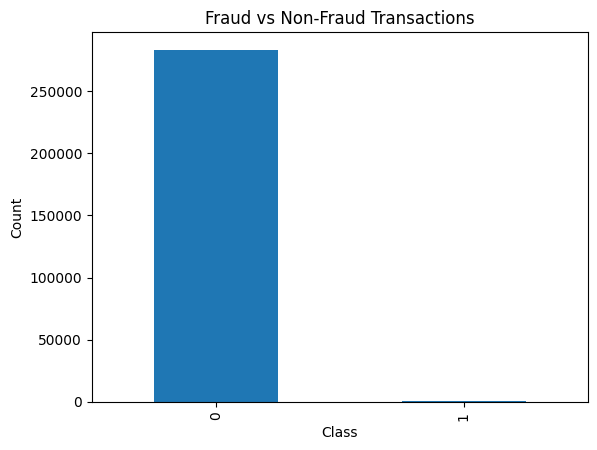

In [29]:
credit_df['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Insight

Figure 1 shows that the dataset is highly imbalanced. The number of non-fraudulent transactions is significantly larger than the number of fraudulent transactions.

This is an important finding because a model can achieve high accuracy by mostly predicting the majority class. Therefore, accuracy alone will not be sufficient for evaluating model performance. Metrics such as precision, recall, and F1-score will be more appropriate for assessing fraud detection effectiveness.

This insight directly supports RQ1, which focuses on evaluating how effectively anomaly detection techniques can identify fraudulent transactions in an imbalanced dataset.

In [39]:
fraud_percent = credit_df['Class'].value_counts(normalize=True) * 100
print(fraud_percent)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


### Insight

Fraudulent transactions constitute only 0.1667% of the dataset, while non-fraudulent transactions account for 99.8333%.

This confirms an extreme class imbalance, which presents a significant challenge for traditional classification models. A model can achieve high accuracy by simply predicting all transactions as non-fraudulent.

Therefore, evaluation metrics such as precision, recall, and F1-score are more appropriate for assessing model performance. Additionally, anomaly detection techniques are better suited for identifying such rare events.

This finding is directly relevant to RQ1, as it highlights the need for specialized methods to effectively detect fraudulent transactions in highly imbalanced datasets.

## Transaction Amount Distribution

This step analyzes the distribution of transaction amounts to understand overall spending behavior and identify potential outliers.

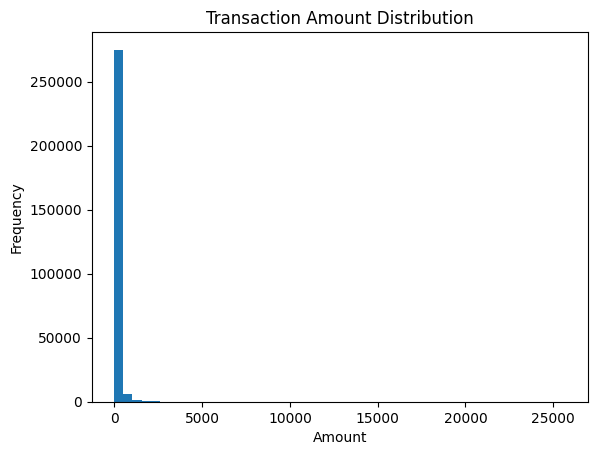

In [44]:
plt.hist(credit_df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

### Insight

Figure 3 shows that the transaction amount distribution is highly right-skewed. The majority of transactions are concentrated at lower values, while a very small number of transactions extend into extremely high amounts.

This indicates that most customer activity involves small-value transactions, with a few high-value outliers. The presence of these outliers suggests variability in transaction behavior, which may be important for identifying anomalies.

However, since fraudulent transactions can occur across both low and high transaction values, the amount variable alone may not be sufficient for detecting fraud. It must be analyzed in combination with other features.

This finding contributes to RQ2, which focuses on identifying key features that influence anomaly detection.

## Fraud Transaction Amount Distribution

This step analyzes the distribution of transaction amounts specifically for fraudulent transactions to identify patterns associated with fraud.

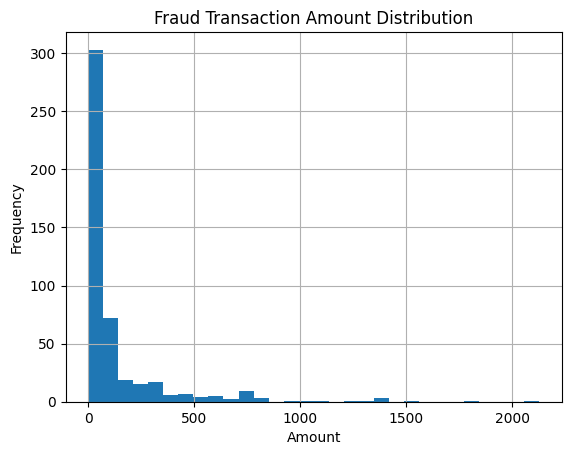

In [48]:
credit_df[credit_df['Class'] == 1]['Amount'].hist(bins=30)
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

### Insight

Figure 4 shows the distribution of transaction amounts for fraudulent transactions. Similar to the overall transaction distribution, fraudulent transactions are also concentrated at lower values, with a long tail extending toward higher amounts.

This indicates that fraud is not limited to high-value transactions. In fact, a significant number of fraudulent transactions occur at relatively low values, possibly as a strategy to avoid detection.

At the same time, the presence of a few high-value fraudulent transactions suggests that fraudsters may also exploit opportunities for larger gains when possible.

This finding highlights that transaction amount alone is not sufficient to distinguish fraudulent activity. Instead, anomaly detection models must consider multiple features simultaneously to improve detection accuracy.

This observation further supports RQ2, emphasizing the importance of multi-feature analysis in identifying anomalies.

## Transaction Time Distribution

This step analyzes how transactions are distributed over time to identify patterns in transaction activity.

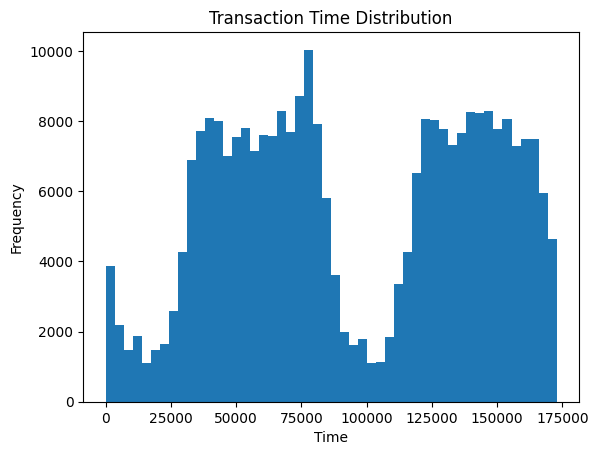

In [52]:
plt.hist(credit_df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

### Insight

Figure 5 shows the distribution of transactions over time. The pattern appears to be non-uniform, with distinct peaks and troughs, indicating varying transaction activity across different time intervals.

The presence of cyclical patterns suggests that transaction behavior follows a time-based rhythm, likely corresponding to daily usage patterns. This indicates that transaction volume fluctuates depending on the time period.

Such temporal variations are important for anomaly detection, as deviations from normal time-based patterns may indicate suspicious activity.

This insight is relevant to RQ2, as incorporating time-based features can enhance the effectiveness of anomaly detection models.

## Fraud Transactions Over Time

This step analyzes how fraudulent transactions are distributed over time to identify any temporal patterns specific to fraud.

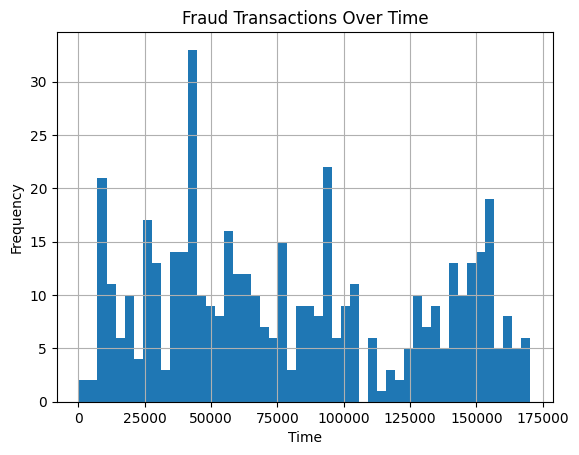

In [56]:
credit_df[credit_df['Class'] == 1]['Time'].hist(bins=50)
plt.title("Fraud Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

### Insight

Figure 6 shows the distribution of fraudulent transactions over time. Unlike the overall transaction distribution, fraudulent transactions appear to be more irregular and scattered across different time intervals.

There is no strong consistent pattern indicating that fraud is concentrated at specific time periods. Instead, fraud occurs sporadically throughout the timeline.

This suggests that fraudulent activity does not strictly follow normal transaction patterns and may be intentionally distributed to avoid detection.

This observation highlights the importance of combining time with other features when building anomaly detection models.

This finding is relevant to RQ2, as it emphasizes the need to incorporate multiple variables for effective fraud detection.

## Correlation Analysis

This step analyzes the relationships between variables using a correlation matrix. It helps identify how features relate to each other and to the target variable.

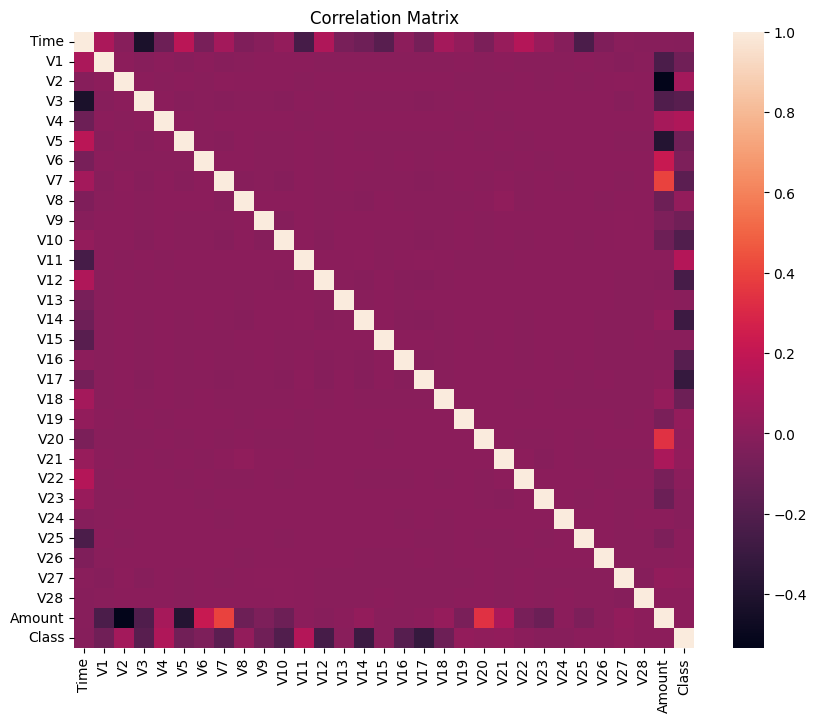

In [60]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(credit_df.corr())
plt.title("Correlation Matrix")
plt.show()

### Insight

Figure 7 presents the correlation matrix of all variables in the dataset. The heatmap shows that most features have low correlation with each other, which is expected since the variables V1–V28 are derived using Principal Component Analysis (PCA).

Due to this transformation, the features are orthogonal (uncorrelated), meaning that each feature captures unique variance in the data. This reduces redundancy and helps improve model performance.

When examining the relationship with the target variable (Class), no single feature shows a very strong correlation. This indicates that fraudulent behavior is influenced by a combination of multiple features rather than any single variable.

This reinforces the need for machine learning models that can capture complex, multi-dimensional relationships in the data.

This finding is directly relevant to RQ2, as it highlights that anomaly detection must rely on multiple features rather than simple threshold-based rules.

# POS Transaction Data Analysis

## Objective

The objective of this analysis is to identify potential revenue leakage patterns in Point-of-Sale (POS) transactions by analyzing discrepancies between actual transaction amounts and rounded values.

## Dataset

The dataset consists of simulated POS transaction records across multiple stores, including transaction amounts, rounded values, and calculated differences.

In [64]:
# Load POS dataset

pos_df = pd.read_csv("pos_dataset.csv")

pos_df.head()

,Transaction_ID,Store_ID,Timestamp,Amount,Rounded_Value,Difference
0,1,S7,2026-01-01 00:00:00,187.79,188.0,0.21
1,2,S4,2026-01-01 00:01:00,185.00,185.0,0.00
2,3,S8,2026-01-01 00:02:00,19.58,20.0,0.42
3,4,S5,2026-01-01 00:03:00,42.89,43.0,0.11
4,5,S7,2026-01-01 00:04:00,36.51,37.0,0.49


In [66]:
print("Rows:", pos_df.shape[0])
print("Columns:", pos_df.shape[1])

Rows: 20000
Columns: 6


## Data Understanding

This step examines the structure, variables, and meaning of the POS dataset.

The dataset contains 20,000 transaction records across multiple stores. Each transaction includes the original amount, rounded value, and the calculated difference between the two.

These differences represent potential discrepancies that may indicate revenue leakage.

In [69]:
pos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  20000 non-null  int64  
 1   Store_ID        20000 non-null  object 
 2   Timestamp       20000 non-null  object 
 3   Amount          20000 non-null  float64
 4   Rounded_Value   20000 non-null  float64
 5   Difference      20000 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 937.6+ KB


In [71]:
pos_df.describe()

,Transaction_ID,Amount,Rounded_Value,Difference
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,104.930131,105.029350,0.099219
std,5773.647028,54.830450,54.828526,0.351678
min,1.000000,10.000000,10.000000,-0.500000
25%,5000.750000,57.735000,58.000000,-0.182500
50%,10000.500000,105.085000,105.000000,0.100000
75%,15000.250000,152.417500,152.000000,0.350000
max,20000.000000,200.000000,200.000000,0.990000


### Observations

- The dataset contains 20,000 transaction records across multiple stores, with no missing values, indicating good data quality.

- The dataset consists of six variables:
  - Transaction_ID: Unique identifier for each transaction
  - Store_ID: Categorical variable representing different store locations
  - Timestamp: Time at which the transaction occurred
  - Amount: Actual transaction amount
  - Rounded_Value: Rounded transaction value recorded
  - Difference: The difference between rounded value and actual amount

- The Difference variable is the most critical feature in this dataset, as it captures the discrepancy between actual and recorded transaction values. This difference may indicate potential revenue leakage.

- The Difference ranges from -0.50 to 0.99, suggesting both under-rounding and over-rounding behaviors across transactions.

- The average difference is approximately 0.099, indicating a small but consistent deviation across transactions, which could accumulate into significant losses at scale.

- The Store_ID variable allows analysis at the store level, enabling identification of specific locations where anomalies or leakages may be concentrated.

- The Timestamp variable provides a temporal dimension, allowing analysis of transaction patterns over time.

Overall, the dataset is well-structured and suitable for analyzing transaction discrepancies and identifying potential anomaly patterns.

## Data Cleaning

The dataset is checked for missing values and duplicate records to ensure data quality before analysis.

In [77]:
# Missing values
pos_df.isnull().sum()

Transaction_ID    0
Store_ID          0
Timestamp         0
Amount            0
Rounded_Value     0
Difference        0
dtype: int64

In [79]:
# Duplicate rows
pos_df.duplicated().sum()

0

### Data Cleaning Observations

- No missing values were found across any of the variables in the dataset.
- No duplicate records were identified.
- The dataset is clean, consistent, and ready for exploratory data analysis.

This ensures that subsequent analysis and results are reliable and not affected by data quality issues.

# Exploratory Data Analysis

## Store-wise Difference Analysis

This step analyzes the average difference between rounded and actual transaction values across different stores.

The objective is to identify stores with higher discrepancies, which may indicate potential revenue leakage.

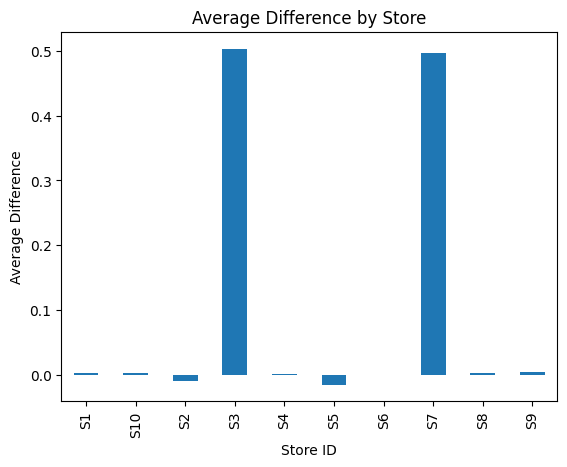

In [84]:
pos_df.groupby("Store_ID")["Difference"].mean().plot(kind='bar')
plt.title("Average Difference by Store")
plt.xlabel("Store ID")
plt.ylabel("Average Difference")
plt.show()

### Insight

Figure 8 shows the average difference between rounded and actual transaction values across different stores.

Most stores exhibit an average difference close to zero, indicating consistent and expected rounding behavior. However, two stores, S3 and S7, show significantly higher positive average differences compared to others.

This suggests that these stores consistently round transaction values upward, resulting in a systematic accumulation of positive differences. Such behavior may indicate potential revenue leakage or intentional rounding manipulation.

The consistency of this pattern across transactions implies that the discrepancy is not random but may be operational or behavioral in nature.

This finding is highly relevant to RQ3, as it demonstrates how anomaly detection techniques can be used to identify store-level irregularities and potential leakage patterns.

## Total Difference (Potential Leakage) by Store

This step analyzes the total accumulated difference between rounded and actual transaction values across each store.

The objective is to quantify the overall impact of discrepancies and identify stores contributing most to potential revenue leakage.

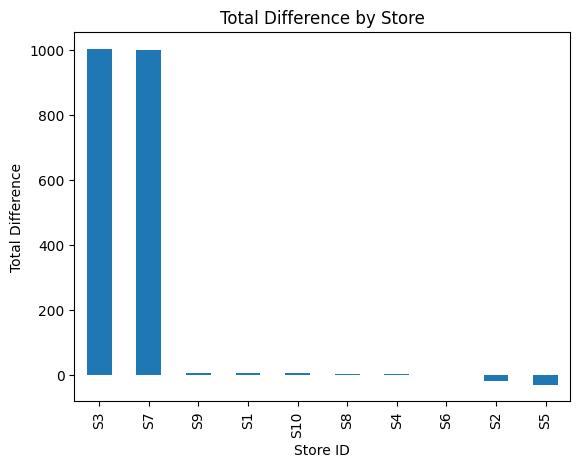

In [88]:
pos_df.groupby("Store_ID")["Difference"].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Total Difference by Store")
plt.xlabel("Store ID")
plt.ylabel("Total Difference")
plt.show()

### Insight

Figure 9 shows the total accumulated difference between rounded and actual transaction values across stores, representing potential revenue leakage.

Stores S3 and S7 exhibit significantly higher total differences compared to all other stores, indicating that they contribute disproportionately to the overall discrepancy.

While most stores have minimal or near-zero total differences, the large accumulation observed in S3 and S7 suggests a systematic pattern rather than random variation.

This implies that even small per-transaction differences, when consistently applied, can result in substantial cumulative impact over time.

Additionally, some stores show negative total differences, indicating under-rounding, which further highlights inconsistency in transaction handling across stores.

This finding is highly relevant to RQ3, as it demonstrates how anomaly detection techniques can identify not only anomalous behavior but also quantify its financial impact at a store level.

## Distribution of Transaction Difference

This step analyzes the distribution of the difference between rounded and actual transaction values across all transactions.

The objective is to understand whether the differences are random or exhibit a systematic pattern.

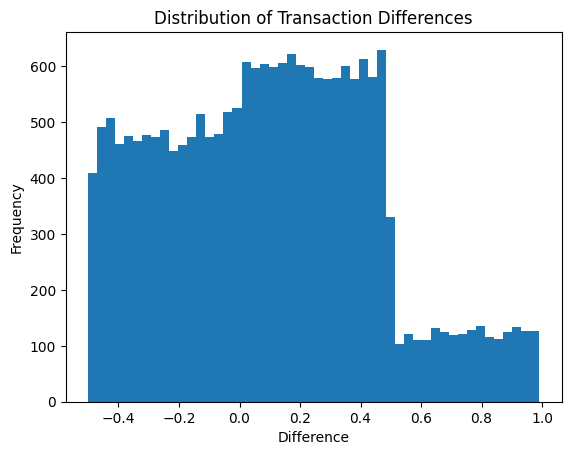

In [92]:
plt.hist(pos_df['Difference'], bins=50)
plt.title("Distribution of Transaction Differences")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

### Insight

Figure 10 shows the distribution of transaction differences across all POS transactions. The distribution spans both negative and positive values, indicating the presence of both under-rounding and over-rounding behavior.

However, the distribution appears skewed toward positive differences, suggesting that rounding up occurs more frequently than rounding down.

This indicates a systematic bias in rounding behavior, where transactions are more often rounded in a way that creates a positive difference. Over time, such small positive differences can accumulate into significant revenue leakage.

The presence of a concentration of values between 0 and 0.5 further supports the idea that rounding practices are not purely random but follow a consistent pattern.

This finding is highly relevant to RQ3, as it highlights how anomaly detection can uncover systematic biases in transaction processing that lead to financial impact.

## Anomaly Identification Based on Transaction Difference

This step identifies anomalous transactions based on unusually high differences between rounded and actual transaction values.

Transactions with a difference greater than 0.5 are flagged as potential anomalies.

In [96]:
# Create anomaly flag

pos_df['Anomaly_Flag'] = pos_df['Difference'].apply(lambda x: 1 if x > 0.5 else 0)

# Count anomalies
pos_df['Anomaly_Flag'].value_counts()

Anomaly_Flag
0    18022
1     1978
Name: count, dtype: int64

### Insight

Out of 20,000 transactions, 1,978 transactions have been flagged as anomalies based on the defined threshold (Difference > 0.5), representing approximately 9.89% of the total transactions.

This indicates that a notable proportion of transactions exhibit unusually high differences between rounded and actual values, which may contribute to revenue leakage.

While the majority of transactions appear normal, the presence of nearly 10% anomalous transactions suggests that discrepancies are not isolated incidents but may reflect underlying systematic behavior.

This finding is relevant to RQ3, as it demonstrates how anomaly detection techniques can be applied to identify potentially problematic transactions in POS systems.

## Store-wise Anomaly Analysis

This step analyzes the distribution of anomalous transactions across stores to identify locations contributing most to irregularities.

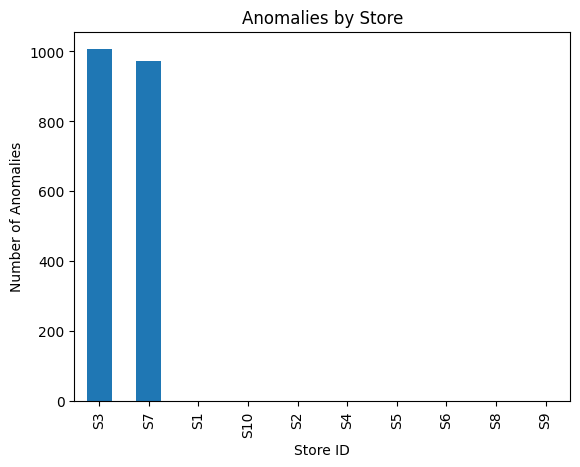

In [100]:
pos_df.groupby("Store_ID")["Anomaly_Flag"].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Anomalies by Store")
plt.xlabel("Store ID")
plt.ylabel("Number of Anomalies")
plt.show()

### Insight

Figure 11 shows the distribution of anomalous transactions across stores based on the defined anomaly threshold.

Stores S3 and S7 account for the vast majority of anomalous transactions, while all other stores show negligible or no anomalies. This indicates a highly concentrated pattern of irregular behavior.

The dominance of anomalies in only a few stores suggests that the discrepancies are not random across the system but are localized to specific operational units.

This strongly supports the hypothesis that systematic rounding behavior or operational practices at these stores are contributing to potential revenue leakage.

The concentration of anomalies in specific stores provides actionable insights for targeted investigation, monitoring, and control measures.

This finding is directly relevant to RQ3, as it demonstrates how anomaly detection techniques can identify and localize irregular patterns within distributed systems.

## Credit Card Fraud Detection Modeling

The modeling phase evaluates whether machine learning techniques can identify fraudulent transactions in a highly imbalanced dataset.

Two modeling approaches are used:

1. Logistic Regression as a baseline supervised classification model.
2. Isolation Forest as an anomaly detection model suitable for identifying rare events.

The target variable is Class, where:
- 0 = Non-fraudulent transaction
- 1 = Fraudulent transaction

In [104]:
# Define features and target variable

X = credit_df.drop("Class", axis=1)
y = credit_df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (283726, 30)
Target shape: (283726,)


In [106]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (198608, 30)
Testing features: (85118, 30)
Training target: (198608,)
Testing target: (85118,)


### Data Preparation Observations

- The dataset was split into training (70%) and testing (30%) sets to evaluate model performance.
- Stratified sampling was used to preserve the class imbalance in both training and testing datasets.
- The training dataset contains 198,608 records, while the testing dataset contains 85,118 records.

Maintaining class distribution is critical in fraud detection problems, as it ensures that both datasets reflect the real-world imbalance between fraudulent and non-fraudulent transactions.

This step prepares the dataset for building and evaluating machine learning models.

## Feature Scaling

The Amount and Time variables are scaled to bring them to a similar range as other features.

Scaling is important for models like Logistic Regression to ensure stable and efficient learning.

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale Amount and Time
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

## Logistic Regression Model

Logistic Regression is used as a baseline supervised classification model to identify fraudulent transactions.

Given the class imbalance, class weights are adjusted to give higher importance to the minority (fraud) class.

In [113]:
from sklearn.linear_model import LogisticRegression

# Initialize model with class imbalance handling
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [117]:
 # Predict on test data
y_pred = lr_model.predict(X_test)

In [119]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[82719  2257]
 [   16   126]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     84976
           1       0.05      0.89      0.10       142

    accuracy                           0.97     85118
   macro avg       0.53      0.93      0.54     85118
weighted avg       1.00      0.97      0.98     85118



### Insight

The Logistic Regression model was evaluated using a confusion matrix and classification metrics.

The model achieved a recall of 0.89 for fraudulent transactions, indicating that it successfully identified 89% of actual fraud cases. This is a strong result, as detecting fraud is typically more important than overall accuracy in such problems.

However, the precision for fraud detection is low at 0.05, meaning that many non-fraudulent transactions are incorrectly classified as fraud (false positives). This is reflected in the confusion matrix, where 2,257 non-fraudulent transactions were misclassified.

The overall accuracy of 97% appears high but is misleading due to the severe class imbalance in the dataset.

This trade-off between recall and precision highlights a common challenge in fraud detection: maximizing fraud detection while minimizing false alarms.

This finding is directly relevant to RQ1, as it demonstrates that while traditional classification models can detect fraud effectively, they may not be optimal due to high false positive rates. This supports the need for anomaly detection approaches.

## Isolation Forest Model

Isolation Forest is an unsupervised anomaly detection algorithm that identifies rare and unusual patterns in the data.

It works by isolating observations, where anomalies are expected to be easier to isolate than normal observations.

Given the extreme class imbalance in fraud detection, Isolation Forest is well-suited for identifying fraudulent transactions.

In [123]:
from sklearn.ensemble import IsolationForest

# Initialize model
iso_model = IsolationForest(contamination=0.002, random_state=42)

# Train model
iso_model.fit(X_train)

IsolationForest(contamination=0.002, random_state=42)

In [125]:
# Predict anomalies
iso_pred = iso_model.predict(X_test)

# Convert output:
# -1 → anomaly (fraud)
#  1 → normal

iso_pred = [1 if x == -1 else 0 for x in iso_pred]

In [127]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, iso_pred))

print("\nClassification Report:")
print(classification_report(y_test, iso_pred))

Confusion Matrix:
[[84851   125]
 [  102    40]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.24      0.28      0.26       142

    accuracy                           1.00     85118
   macro avg       0.62      0.64      0.63     85118
weighted avg       1.00      1.00      1.00     85118



### Insight

The Isolation Forest model was evaluated to identify fraudulent transactions using an anomaly detection approach.

The model achieved a recall of 0.28 for fraudulent transactions, meaning it was able to correctly identify 28% of actual fraud cases. While this is lower than Logistic Regression, the precision improved significantly to 0.24, compared to 0.05 in the previous model.

This indicates that Isolation Forest produces fewer false positives, making it more reliable in terms of accuracy of detected anomalies.

The confusion matrix shows that only 125 non-fraudulent transactions were incorrectly classified as fraud, which is significantly lower than the 2,257 false positives observed in Logistic Regression.

This highlights a key trade-off:
- Logistic Regression achieves higher recall but produces many false alarms
- Isolation Forest reduces false positives but misses more fraud cases

This trade-off is critical in real-world fraud detection systems, where balancing detection accuracy and operational efficiency is essential.

This finding directly supports RQ1, demonstrating that anomaly detection models provide a more controlled and practical approach to identifying fraudulent transactions in highly imbalanced datasets.

### Model Comparison

A comparison between Logistic Regression and Isolation Forest highlights important differences:

- Logistic Regression achieved high recall (0.89) but very low precision (0.05), resulting in a large number of false positives.
- Isolation Forest improved precision (0.24) significantly but had lower recall (0.28), missing more fraud cases.

This comparison demonstrates that no single model is perfect, and model selection depends on the business objective:
- If the goal is to detect maximum fraud → Logistic Regression is preferable
- If the goal is to reduce false alerts → Isolation Forest is more suitable

This analysis reinforces the need for a balanced or hybrid approach in real-world fraud detection systems.

## POS Anomaly Detection Model

For the POS dataset, a rule-based anomaly detection approach is used.

Transactions are classified as anomalous if the difference between rounded and actual transaction values exceeds a defined threshold.

This approach is chosen because:
- The dataset is structured and interpretable
- The Difference variable directly represents discrepancies
- Business rules can effectively capture abnormal behavior

This method provides transparency and is easy to implement in real-world operational systems.

## Feature Selection

The key feature used for anomaly detection is:

- Difference: Represents the discrepancy between actual and rounded transaction values

Additional grouping variables:
- Store_ID: Used to identify store-level anomaly patterns
- Timestamp: Used for temporal analysis

No complex feature engineering is required, as the Difference variable directly captures the anomaly signal.

In [133]:
# Define anomaly threshold
threshold = 0.5

# Create anomaly flag
pos_df['Anomaly_Flag'] = pos_df['Difference'].apply(lambda x: 1 if x > threshold else 0)

# Count anomalies
pos_df['Anomaly_Flag'].value_counts()

Anomaly_Flag
0    18022
1     1978
Name: count, dtype: int64

### Model Interpretation

The rule-based model identifies transactions with unusually high differences as anomalies.

This approach aligns with business logic, where excessive rounding differences may indicate potential revenue leakage.

The simplicity of the model makes it highly interpretable and suitable for operational monitoring systems.

In [136]:
# Anomalies by store
pos_df.groupby("Store_ID")["Anomaly_Flag"].sum().sort_values(ascending=False)

Store_ID
S3     1006
S7      972
S1        0
S10       0
S2        0
S4        0
S5        0
S6        0
S8        0
S9        0
Name: Anomaly_Flag, dtype: int64

### Insight

The rule-based anomaly detection model identified 1,978 anomalous transactions based on the defined threshold.

Store-level analysis reveals that all anomalous transactions are concentrated in two stores: S3 and S7. Specifically, S3 accounts for 1,006 anomalies and S7 accounts for 972 anomalies, while all other stores show zero anomalous transactions.

This indicates a highly localized pattern of irregular behavior, suggesting that the discrepancies are not random but are driven by specific operational practices at these stores.

The complete absence of anomalies in other stores reinforces the validity of the anomaly detection logic and highlights that the issue is not systemic across the entire network.

This finding is highly significant from a business perspective, as it enables targeted investigation and corrective action at specific locations, rather than applying broad controls across all stores.

This result directly supports RQ3, demonstrating that anomaly detection techniques can effectively identify and localize revenue leakage patterns within POS systems.

## Machine Learning-Based Anomaly Detection (POS)

In addition to the rule-based approach, a machine learning-based anomaly detection model is implemented using Isolation Forest.

Isolation Forest is suitable for detecting anomalies in datasets where abnormal patterns are rare and differ significantly from normal behavior.

This approach helps validate and enhance the anomaly detection process by identifying patterns beyond simple threshold-based rules.

In [140]:
# Select relevant features for modeling
pos_features = pos_df[['Amount', 'Difference']]

### Feature Selection

The following features are used for anomaly detection:

- Amount: Represents transaction value
- Difference: Captures discrepancy between actual and rounded values

These features are sufficient to identify abnormal transaction patterns in POS data.

In [145]:
from sklearn.ensemble import IsolationForest

# Initialize model
pos_iso = IsolationForest(contamination=0.1, random_state=42)

# Train model
pos_iso.fit(pos_features)

IsolationForest(contamination=0.1, random_state=42)

In [147]:
# Predict anomalies
pos_df['ML_Anomaly'] = pos_iso.predict(pos_features)

# Convert output: -1 → anomaly, 1 → normal
pos_df['ML_Anomaly'] = pos_df['ML_Anomaly'].apply(lambda x: 1 if x == -1 else 0)

# Count anomalies
pos_df['ML_Anomaly'].value_counts()

ML_Anomaly
0    18001
1     1999
Name: count, dtype: int64

### Insight

The Isolation Forest model identifies anomalous transactions based on patterns in transaction amount and difference.

The results provide an additional validation layer over the rule-based model, helping to detect anomalies that may not be captured by simple thresholds.

In [150]:
pos_df.groupby("Store_ID")["ML_Anomaly"].sum().sort_values(ascending=False)

Store_ID
S3     616
S7     612
S10    106
S8     104
S4     100
S9     100
S2      97
S5      95
S6      86
S1      83
Name: ML_Anomaly, dtype: int64

### Insight

The Isolation Forest model identified 1,999 anomalous transactions, which is consistent with the rule-based model that identified 1,978 anomalies.

However, unlike the rule-based approach, which concentrated anomalies exclusively in stores S3 and S7, the machine learning model detected anomalies across all stores, though with significantly higher counts in S3 and S7.

Specifically, stores S3 and S7 continue to exhibit the highest number of anomalies (616 and 612 respectively), confirming the strong anomaly signal observed earlier.

At the same time, the model also identifies smaller numbers of anomalies in other stores, suggesting that subtle irregular patterns may exist beyond the obvious threshold-based discrepancies.

This demonstrates that:
- Rule-based models are effective for identifying clear and direct anomalies
- Machine learning models can detect more nuanced and distributed anomaly patterns

The combination of both approaches provides a more comprehensive anomaly detection framework.

This finding strengthens RQ3, showing that hybrid anomaly detection techniques can improve both detection coverage and interpretability in POS systems.

### Comparison of Rule-Based and Machine Learning Approaches

The rule-based model identified anomalies strictly based on transaction difference thresholds, resulting in highly localized anomalies in specific stores.

In contrast, the Isolation Forest model identified anomalies across all stores, capturing both strong and subtle irregular patterns.

Key observations:
- Rule-based model: High interpretability, precise localization
- ML model: Broader detection, captures hidden patterns

This comparison highlights the advantage of combining both approaches to achieve a balance between interpretability and detection capability.

Such a hybrid framework is highly applicable in real-world systems where both transparency and accuracy are required.

## Preliminary Results

### Display and Analysis of Results

The preliminary results from both the credit card fraud dataset and the POS dataset provide valuable insights into anomaly detection performance.

#### Credit Card Fraud Detection

Two models were evaluated: Logistic Regression and Isolation Forest.

The Logistic Regression model demonstrated strong fraud detection capability, achieving a recall of 0.89. This indicates that the model successfully identified 89% of fraudulent transactions. However, this came at the cost of a very low precision of 0.05, meaning that a large number of non-fraudulent transactions were incorrectly classified as fraud.

The confusion matrix further highlights this issue, with 2,257 false positives. This suggests that while the model is effective at detecting fraud, it may generate excessive alerts, which can be operationally inefficient.

In contrast, the Isolation Forest model showed a different performance pattern. It achieved a lower recall of 0.28, indicating that fewer fraud cases were detected. However, it significantly improved precision to 0.24, reducing false positives to only 125 transactions.

This demonstrates a clear trade-off:
- Logistic Regression prioritizes fraud detection (high recall)
- Isolation Forest prioritizes precision (low false positives)

#### POS Anomaly Detection

For the POS dataset, both rule-based and machine learning-based anomaly detection approaches were applied.

The rule-based model identified 1,978 anomalous transactions, representing approximately 9.89% of the dataset. These anomalies were entirely concentrated in two stores, S3 and S7, indicating a strong and localized pattern of discrepancy.

The Isolation Forest model identified 1,999 anomalous transactions, closely aligning with the rule-based model in terms of total anomaly count. However, it distributed anomalies across all stores, while still highlighting S3 and S7 as the primary contributors.

This indicates that:
- Rule-based approach effectively identifies clear and direct anomalies
- Machine learning approach captures both strong and subtle anomaly patterns



### Performance Evaluation

#### Credit Card Dataset

Model performance was evaluated using precision, recall, and F1-score.

- Logistic Regression:
  - Recall: 0.89
  - Precision: 0.05
  - F1-score: Low due to high false positives

- Isolation Forest:
  - Recall: 0.28
  - Precision: 0.24
  - F1-score: Improved balance compared to Logistic Regression

These results highlight that no single model provides optimal performance. The choice of model depends on business priorities:
- High recall models are suitable when detecting maximum fraud is critical
- High precision models are preferred when minimizing false alerts is important

#### POS Dataset

Since the POS dataset uses anomaly detection rather than classification, performance is evaluated based on consistency, interpretability, and pattern detection.

- Rule-based model:
  - High interpretability
  - Clearly identifies anomaly concentration in specific stores
  - Suitable for operational monitoring

- Isolation Forest model:
  - Broader anomaly detection capability
  - Identifies both major and minor irregularities
  - Provides validation for rule-based findings

The consistency between both approaches strengthens confidence in the results and supports the use of a hybrid anomaly detection framework.

Overall, the preliminary results demonstrate that anomaly detection techniques are effective in identifying irregular patterns in both financial transactions and operational datasets.